In [1]:
import numpy as np 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader , TensorDataset
import matplotlib.pyplot as plt

In [2]:
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 1. LOAD MNIST DATA
# ---------------------------
transform = transforms.ToTensor()

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# convert to tensors
X = mnist_data.data.float()   # (60000, 28, 28)
y = mnist_data.targets        # (60000,)

# flatten
X = X.view(X.shape[0], -1)    # (60000, 784)

# ---------------------------
# 2. TRAIN-TEST SPLIT
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101
)

# ---------------------------
# 3. SCALING (like your code)
# ---------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# convert back to tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

# ---------------------------
# 4. DATASET + DATALOADER
# ---------------------------
train_data = TensorDataset(X_train, y_train)
test_data  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_data, batch_size=len(test_data), shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 506kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.62MB/s]
/tmp/ipython-input-3964664633.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
/tmp/ipython-input-3964664633.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test  = torch.tensor(y_test, dtype=torch.long)


In [3]:
# create a class for the model WITH BATCH NORM

class ANNclassifier(nn.Module):
  def __init__(self):
    super().__init__()

    ### input layer
    self.input = nn.Linear(784,128)
    
    ### hidden layers
    self.fc1    = nn.Linear(128,64)
    self.bnorm1 = nn.BatchNorm1d(64) # the number of units into this layer
    self.fc2    = nn.Linear(64,32)
    self.bnorm2 = nn.BatchNorm1d(32) # the number of units into this layer

    ### output layer
    self.output = nn.Linear(32,10)
  
  # forward pass
  def forward(self, x):

    # input layer
    x = self.input(x)
    x = F.relu(x)

    # hidden layer 1
    x = self.fc1(x)
    x = self.bnorm1(x)
    x = F.relu(x)

    # hidden layer 2
    x = self.fc2(x)
    x = self.bnorm2(x)
    x = F.relu(x)

    # output layer
    x = self.output(x)

    return x

In [4]:
winenet = ANNclassifier()

numepochs = 1000

def trainTheModel():

  lossfun = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(winenet.parameters(), lr=0.01)

  losses   = torch.zeros(numepochs)
  trainAcc = []
  testAcc  = []

  for epochi in range(numepochs):

    winenet.train()

    batchAcc  = []
    batchLoss = []

    for X, y in train_loader:

      # forward
      yHat = winenet(X)
      loss = lossfun(yHat, y)

      # backward
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batchLoss.append(loss.item())

      # ✅ FIX 1: correct training accuracy
      preds = torch.argmax(yHat, dim=1)
      acc = 100 * torch.mean((preds == y).float()).item()
      batchAcc.append(acc)

    trainAcc.append(np.mean(batchAcc))
    losses[epochi] = np.mean(batchLoss)

    # ===== TEST =====
    winenet.eval()

    X, y = next(iter(test_loader))

    with torch.no_grad():
      yHat = winenet(X)

      # ✅ FIX 2: correct test accuracy
      preds = torch.argmax(yHat, dim=1)
      acc = 100 * torch.mean((preds == y).float()).item()
      testAcc.append(acc)

  return trainAcc, testAcc, losses

In [5]:

trainAccWith,testAccWith,lossesWith = trainTheModel()

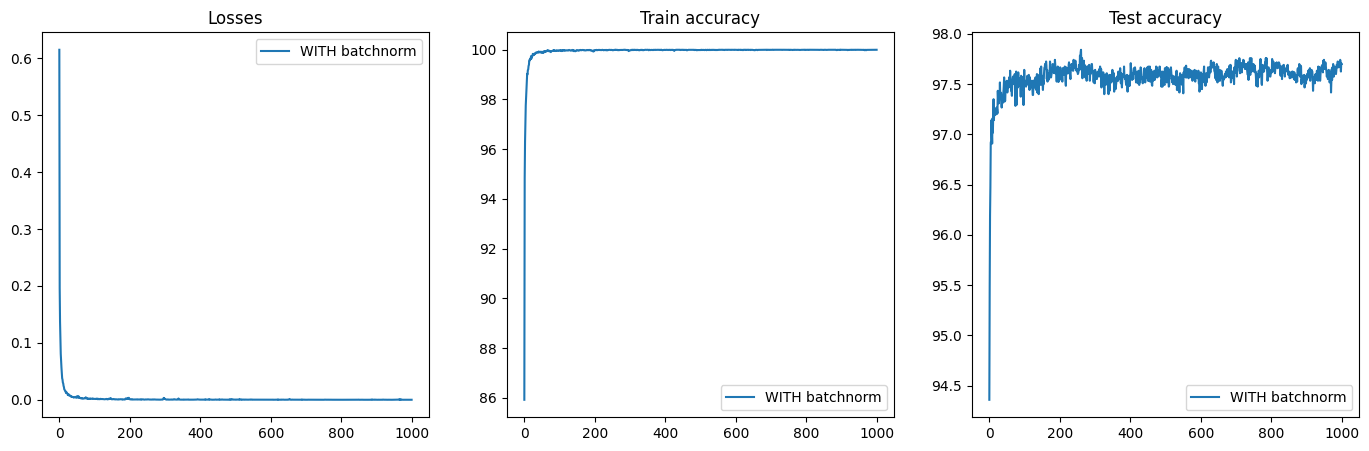

In [6]:
# plot the results
fig,ax = plt.subplots(1,3,figsize=(17,5))

ax[0].plot(lossesWith,label='WITH batchnorm')
ax[0].set_title('Losses')
ax[0].legend()

ax[1].plot(trainAccWith,label='WITH batchnorm')

ax[1].set_title('Train accuracy')
ax[1].legend()

ax[2].plot(testAccWith,label='WITH batchnorm')

ax[2].set_title('Test accuracy')
ax[2].legend()

plt.show()